### Python Libraries and (required) preinstalled data structures

In [1]:

# Necessary libraries

import pandas as pd
import kagglehub
import networkx as nx
import matplotlib.pyplot as plt

from collections import deque
from collections import defaultdict
import heapq

/workspaces/Application-of-AI/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Kaggle Dataset - Indian Cities


In [2]:

#kagglehub.login()

# If an error occurs, please use the kagglehub (older) version in the requirements.txt file
# Because of a bug on the most recent update it may fail

# Download selected version
path = kagglehub.dataset_download("kbdharun/a-star-algorithm-route-planning-dataset/versions/2")

print("Path to dataset files:", path)

df = pd.read_csv(f'{path}/indian-cities-dataset.csv')

print(df.head())

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/kbdharun/a-star-algorithm-route-planning-dataset/versions/2
   Origin Destination  Distance
0  Mumbai        Pune       148
1  Mumbai   Ahmedabad       526
2    Pune      Mumbai       150
3    Pune   Ahmedabad       660
4    Pune   Hyderabad       560


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Origin       99 non-null     str  
 1   Destination  99 non-null     str  
 2   Distance     99 non-null     int64
dtypes: int64(1), str(2)
memory usage: 2.4 KB
None


In [4]:
graph = defaultdict(dict)

for origin, destination, distance in zip(df['Origin'], df['Destination'], df['Distance']):
    graph[origin][destination] = distance
    graph[destination][origin] = distance

In [5]:
# These are the neighboring cities and their distances from the city od Ahmedabad

graph['Ahmedabad']

{'Mumbai': 526, 'Pune': 663, 'Jaipur': 659, 'Udaipur': 257}

## Graph for Pathfinding using NetworkX

/tmp/ipykernel_7844/2010348278.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


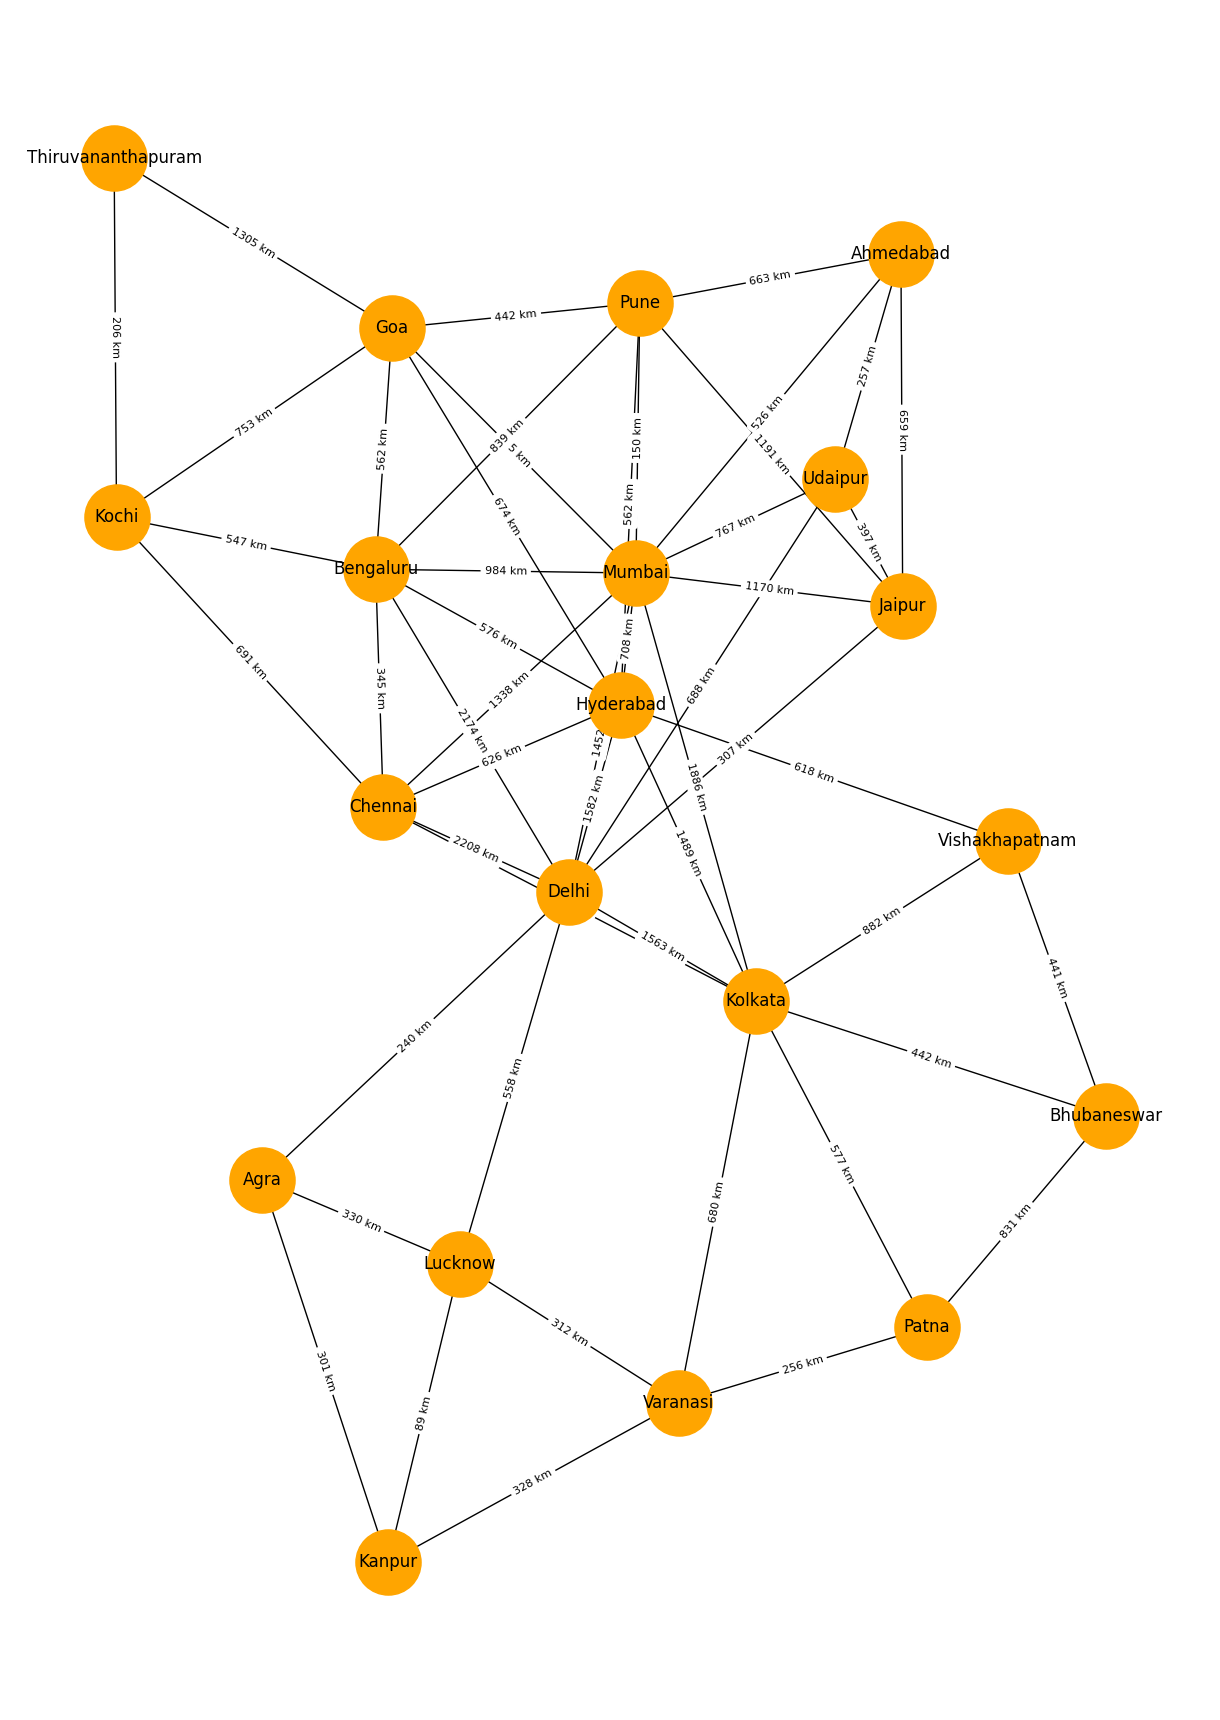

In [6]:
# Let us create a graph representing the cities and the distances between them.

C = nx.Graph()
D = nx.Graph()

for o,d,w in zip(df.Origin, df.Destination, df.Distance):
  C.add_edge(o,d, distance=int(w))

pos = nx.kamada_kawai_layout(C)

plt.figure(figsize=(12,17))
nx.draw(C, pos, with_labels=True, node_color='orange', node_size=2200, font_size=12)

edge_labels = {(u,v): f'{j['distance']} km' for u,v,j in C.edges(data=True)}

nx.draw_networkx_edge_labels(C, pos=pos, edge_labels=edge_labels, font_size=8)

plt.savefig('Indian_Cities')
plt.tight_layout()
plt.show()

In [7]:
# plt.figure(figsize=(12,17))
# nx.draw(graph, pos, with_labels=True, node_color='orange', node_size=2200, font_size=12)

# edge_labels = {(u,v): f'{j['distance']} km' for u,v,j in graph.edges(data=True)}

# nx.draw_networkx_edge_labels(graph, pos=pos, edge_labels=edge_labels, font_size=8)

# plt.savefig('Indian_Cities')
# plt.tight_layout()
# plt.show()

## Breadth-First Search (BFS)

In [ ]:
def bfs(graph, start_node):
  ''' This functions aims to show/mimic how some computational agents 
  can blindly explore a environment. Essentially, this function visits a node and notes its neighbours then visits 
  the next of the ealiest noted nodes taken last visit.  '''

  visited = set()  # Choice of set over other data structutes

  queue = deque([start_node])

  visited.add(start_node)

  i=0

  while queue:
    current_node = queue.popleft()
    print(current_node, end=' ')
    print(i)
    i +=1

    for neighbour in graph[current_node]:
      if neighbour not in visited:
        visited.add(neighbour)
        queue.append(neighbour)

In [9]:
bfs(graph, 'Ahmedabad')

Ahmedabad 0
Mumbai 1
Pune 2
Jaipur 3
Udaipur 4
Goa 5
Delhi 6
Hyderabad 7
Bengaluru 8
Kolkata 9
Chennai 10
Kochi 11
Thiruvananthapuram 12
Agra 13
Lucknow 14
Vishakhapatnam 15
Varanasi 16
Patna 17
Bhubaneswar 18
Kanpur 19


## Shortest path (Dijkstra or Uniform Cost search)



In [10]:
def dijkstra(graph, start):

  queue = [(0,start)]
  distances = {node: float('infinity') for node in graph}
  distances[start] = 0

  while queue:
    current_cost, current_node = heapq.heappop(queue)


    if current_cost > distances[current_node]:
      continue

    for neighbour, weight in graph[current_node].items():
      distance = current_cost + weight

      if distance < distances[neighbour] :
        distances[neighbour]= distance
        heapq.heappush(queue, (distance, neighbour))

  return distances

In [11]:
graph['Ahmedabad']

{'Mumbai': 526, 'Pune': 663, 'Jaipur': 659, 'Udaipur': 257}

In [12]:
dijkstra(graph, 'Ahmedabad')

{'Mumbai': 526,
 'Pune': 663,
 'Ahmedabad': 0,
 'Hyderabad': 1225,
 'Bengaluru': 1502,
 'Jaipur': 654,
 'Udaipur': 257,
 'Chennai': 1847,
 'Goa': 1105,
 'Kochi': 1858,
 'Thiruvananthapuram': 2064,
 'Delhi': 945,
 'Agra': 1185,
 'Lucknow': 1503,
 'Kanpur': 1486,
 'Varanasi': 1814,
 'Patna': 2070,
 'Kolkata': 2412,
 'Bhubaneswar': 2284,
 'Vishakhapatnam': 1843}

In [13]:
route = nx.dijkstra_path(C, 'Ahmedabad', 'Patna', weight='distance')
length = nx.dijkstra_path_length(C, 'Ahmedabad', 'Patna', weight='distance')
print(f'Shortest path from Ahmedabad to Patna: {route}, {length} km')

Shortest path from Ahmedabad to Patna: ['Ahmedabad', 'Udaipur', 'Delhi', 'Agra', 'Kanpur', 'Varanasi', 'Patna'], 2070 km


In [14]:
Dijkstra_path = nx.Graph()
df1 = df[df['Origin'].isin(route) & df['Destination'].isin(route)]

for i, j, d in zip(df1['Origin'], df1['Destination'], df1['Distance']):
    Dijkstra_path.add_edge(i, j, distance=d)


/tmp/ipykernel_7844/2357866745.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


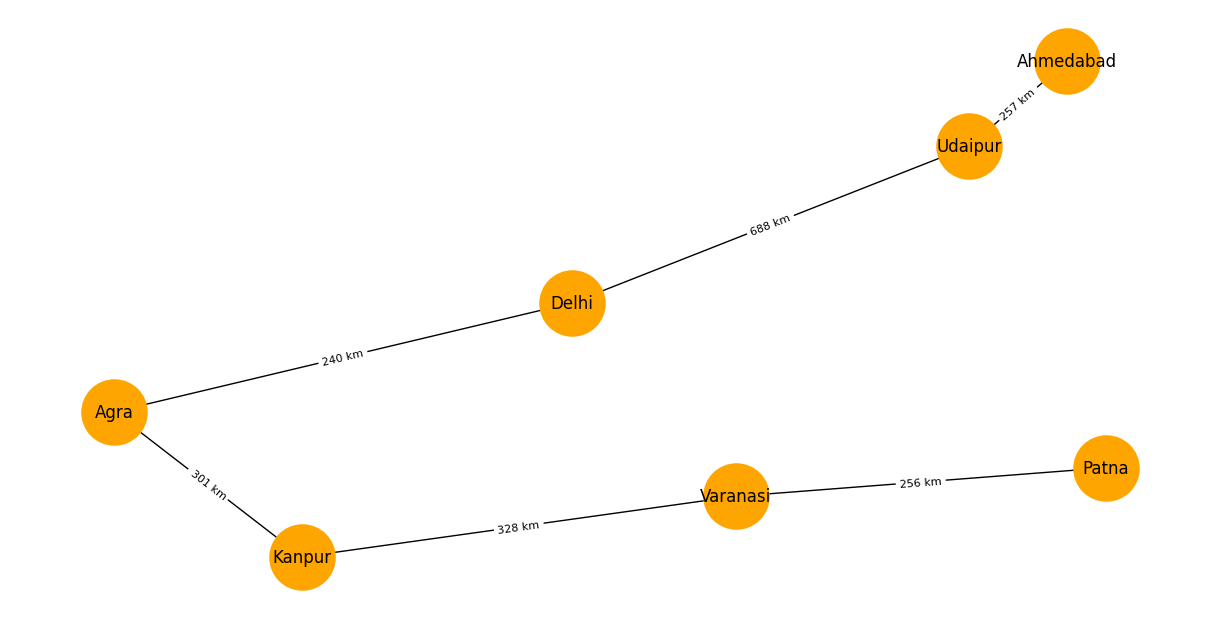

In [15]:
plt.figure(figsize=(12,6))
nx.draw(Dijkstra_path, pos, with_labels=True, node_color='orange', node_size=2200, font_size=12)

edge_labels = {(u,v): f'{j['distance']} km' for u,v,j in Dijkstra_path.edges(data=True)}

nx.draw_networkx_edge_labels(Dijkstra_path, pos=pos, edge_labels=edge_labels, font_size=8)

plt.savefig('Dijkstra_path_Indian_cities')
plt.tight_layout()
plt.show()

## A* Search algorithm

In [16]:
def a_star(graph, start, goal, heuristic):


    queue = [(0 + heuristic[start], 0, start)]
    came_from = {start: None}
    g_score = {node: float('inf') for node in graph}
    g_score[start] = 0

    while queue:
        _, current_cost, current_node = heapq.heappop(queue)

        if current_node == goal:
            return current_cost
        
        for neighbour, weight in graph[current_node].items():
            tentative_g = current_cost + weight

            if tentative_g < g_score[neighbour]:
                g_score[neighbour] = tentative_g
                f_score = tentative_g + heuristic[neighbour]
                heapq.heappush(queue, (f_score, tentative_g, neighbour))
                came_from[neighbour] = current_node
    
    return None

In [17]:
heuristic = nx.single_source_dijkstra_path_length(C, 'Patna', weight='distance')
estimated_path_cost = a_star(graph, 'Ahmedabad', 'Patna', heuristic)

In [18]:
a_star(graph,'Ahmedabad', 'Patna', heuristic)

2070

In [19]:
#a_star(graph,'Ahmedabad', 'Patna', dijkstra(graph, 'Patna'))

2070

In [20]:
# NetworkX

route = nx.astar_path(C, 'Ahmedabad', 'Patna', weight='distance')
length = nx.astar_path_length(C, 'Ahmedabad', 'Patna', weight='distance')
print(route, length)

['Ahmedabad', 'Udaipur', 'Delhi', 'Agra', 'Kanpur', 'Varanasi', 'Patna'] 2070
